In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = sns.load_dataset('titanic')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
df.shape

(891, 15)

In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=['object','category','bool']).columns

Observations:
- Dataset contains ~891 rows and multiple features including numerical and categorical variables
- Target variable is survived
- Features like age, deck, and embarked contain missing values
- Numerical features like fare show high variance

Insights:
- Dataset contains mixed data types requiring preprocessing
- Missing values must be handled before modeling
- fare may contain extreme values (possible outliers)

In [9]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Observations:
- deck has a very high number of missing values
- age has moderate missing values
- embarked has very few missing values


Insights:
- deck is not reliable → should be dropped
- age should be imputed (median preferred due to skew)
- embarked can be filled with mode

In [10]:
from sklearn.impute import SimpleImputer
imputer_median = SimpleImputer(strategy='median')
df['age'] = imputer_median.fit_transform(df[['age']])

In [11]:
imputer_mode = SimpleImputer(strategy='most_frequent')
df['embarked'] = imputer_mode.fit_transform(df[['embarked']]).ravel()
df['embark_town'] = imputer_mode.fit_transform(df[['embark_town']]).ravel()

In [12]:
df.drop(columns=['deck'],inplace=True)
cat_cols = cat_cols.drop(['deck'])
#deck removed due to high number of missing values
cat_cols

Index(['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [13]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     775 non-null    int64   
 1   pclass       775 non-null    int64   
 2   sex          775 non-null    object  
 3   age          775 non-null    float64 
 4   sibsp        775 non-null    int64   
 5   parch        775 non-null    int64   
 6   fare         775 non-null    float64 
 7   embarked     775 non-null    object  
 8   class        775 non-null    category
 9   who          775 non-null    object  
 10  adult_male   775 non-null    bool    
 11  embark_town  775 non-null    object  
 12  alive        775 non-null    object  
 13  alone        775 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 75.1+ KB


In [34]:
df.mean(numeric_only=True)

survived       0.412903
pclass         2.246452
age           29.581187
sibsp          0.529032
parch          0.420645
fare          34.878403
adult_male     0.571613
alone          0.563871
dtype: float64

Observations:
- Age distribution is approximately normal with slight right skew
- Majority of passengers are between 20–40 years
- Fare distribution is highly right-skewed
- Few passengers paid significantly higher fares


Insights:
- Titanic passengers were mostly young adults
- Slight skew indicates presence of older passengers
- Most passengers traveled in lower fare classes
- High fares likely represent premium class passengers

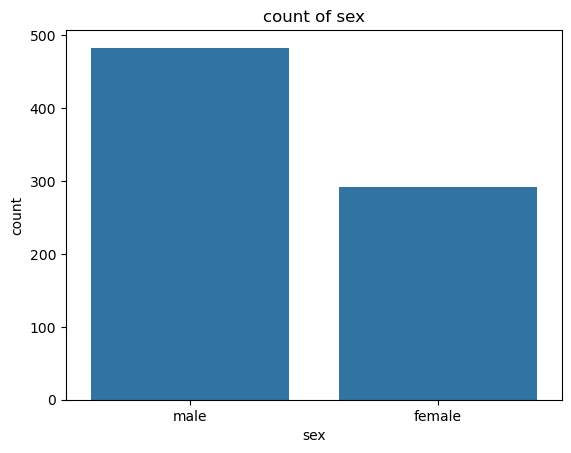

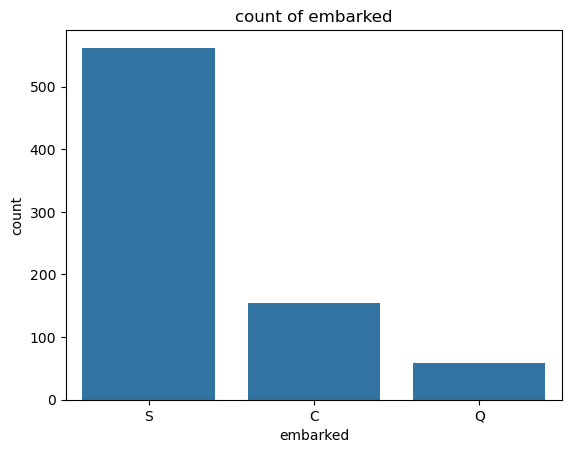

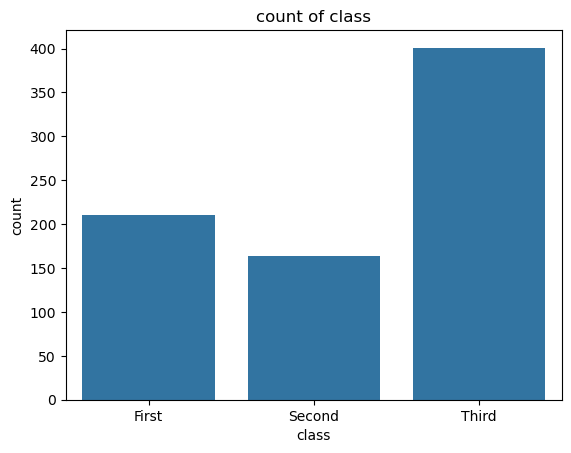

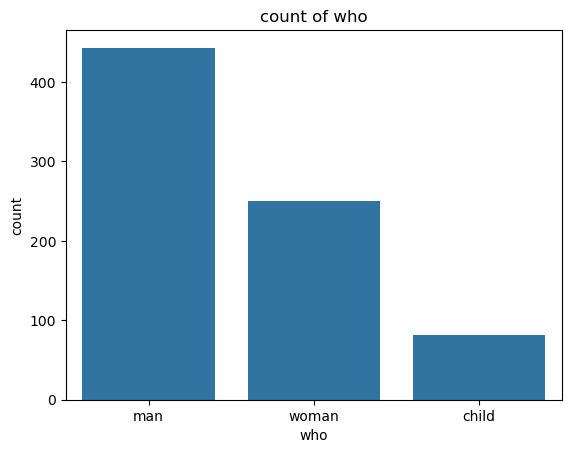

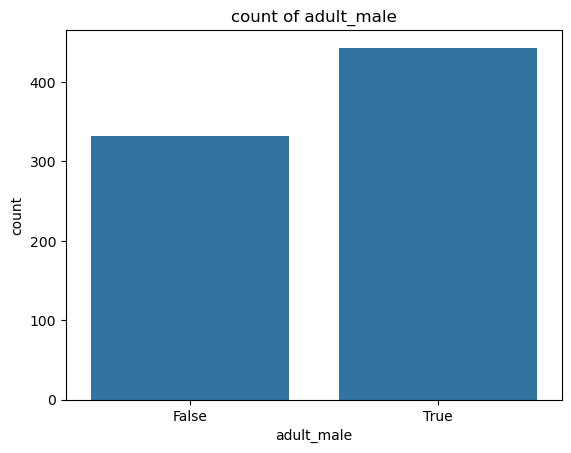

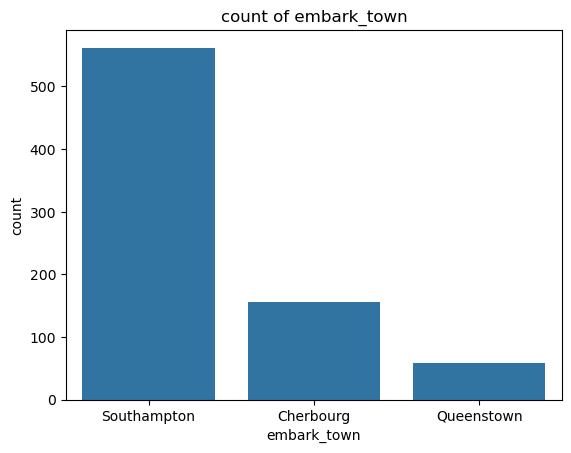

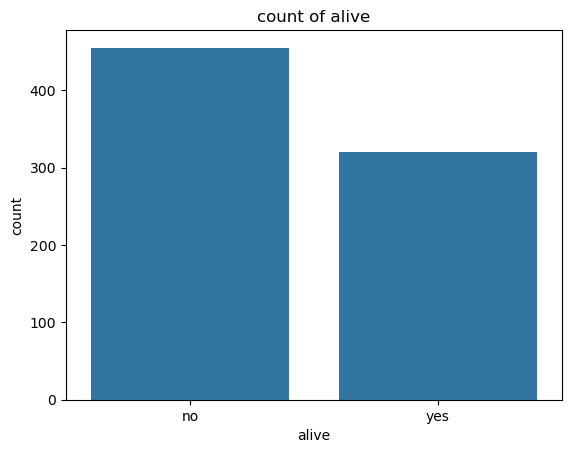

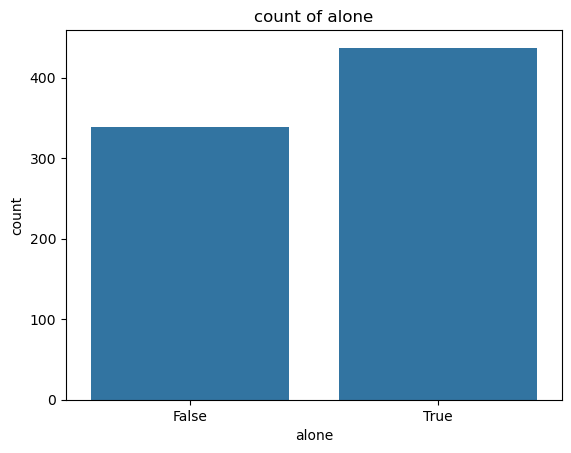

In [16]:
for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.title(f'count of {col}')
    plt.show()

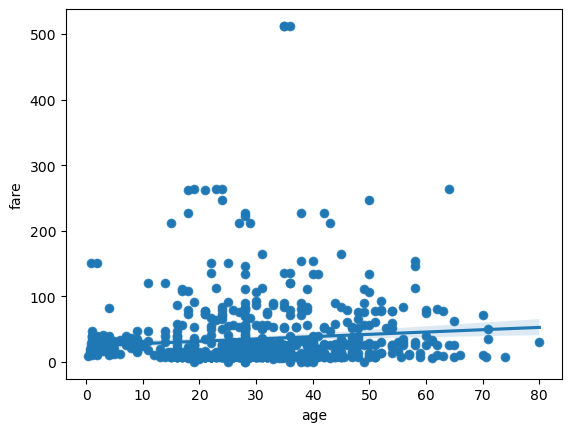

In [17]:
sns.scatterplot(x='age', y='fare', data=df)
sns.regplot(x='age', y='fare', data=df)
plt.show()

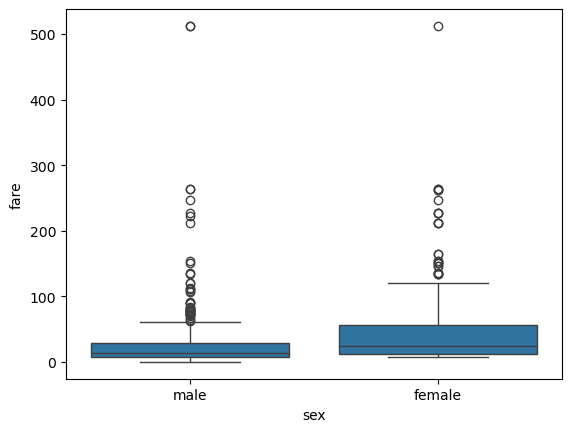

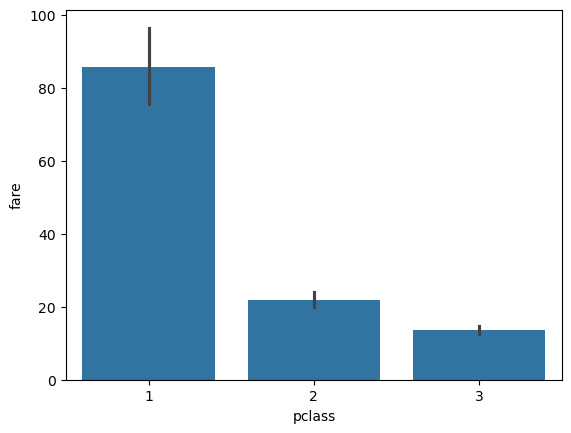

In [18]:
sns.boxplot(x='sex', y='fare', data=df)
plt.show()
sns.barplot(x='pclass', y='fare', data=df)
#shows average of fare is higher for 1st class, then 2nd, then 3rd
plt.show()

In [19]:
pd.crosstab(df['sex'],df['survived'])

survived,0,1
sex,,
female,76,216
male,379,104


In [20]:
pd.crosstab(df['pclass'],df['survived'])

survived,0,1
pclass,,
1,77,133
2,81,83
3,297,104


<Axes: xlabel='pclass', ylabel='survived'>

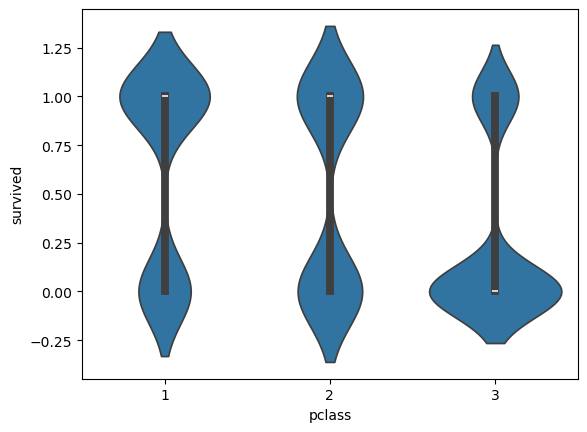

In [23]:
sns.violinplot(x=df['pclass'],y=df['survived'])

Observations:
- Female survival rate is significantly higher than male
- First-class passengers have highest survival rate
- Third-class passengers have lowest survival rate
- No strong relationship between age and fare
- Fare values are spread across all age groups

Insights:
- Gender played a critical role in survival
- Likely due to “women and children first” evacuation policy
- Socioeconomic status strongly influenced survival
- Higher-class passengers likely had better access to lifeboats
- Ticket price is independent of age
- Fare is likely determined by passenger class

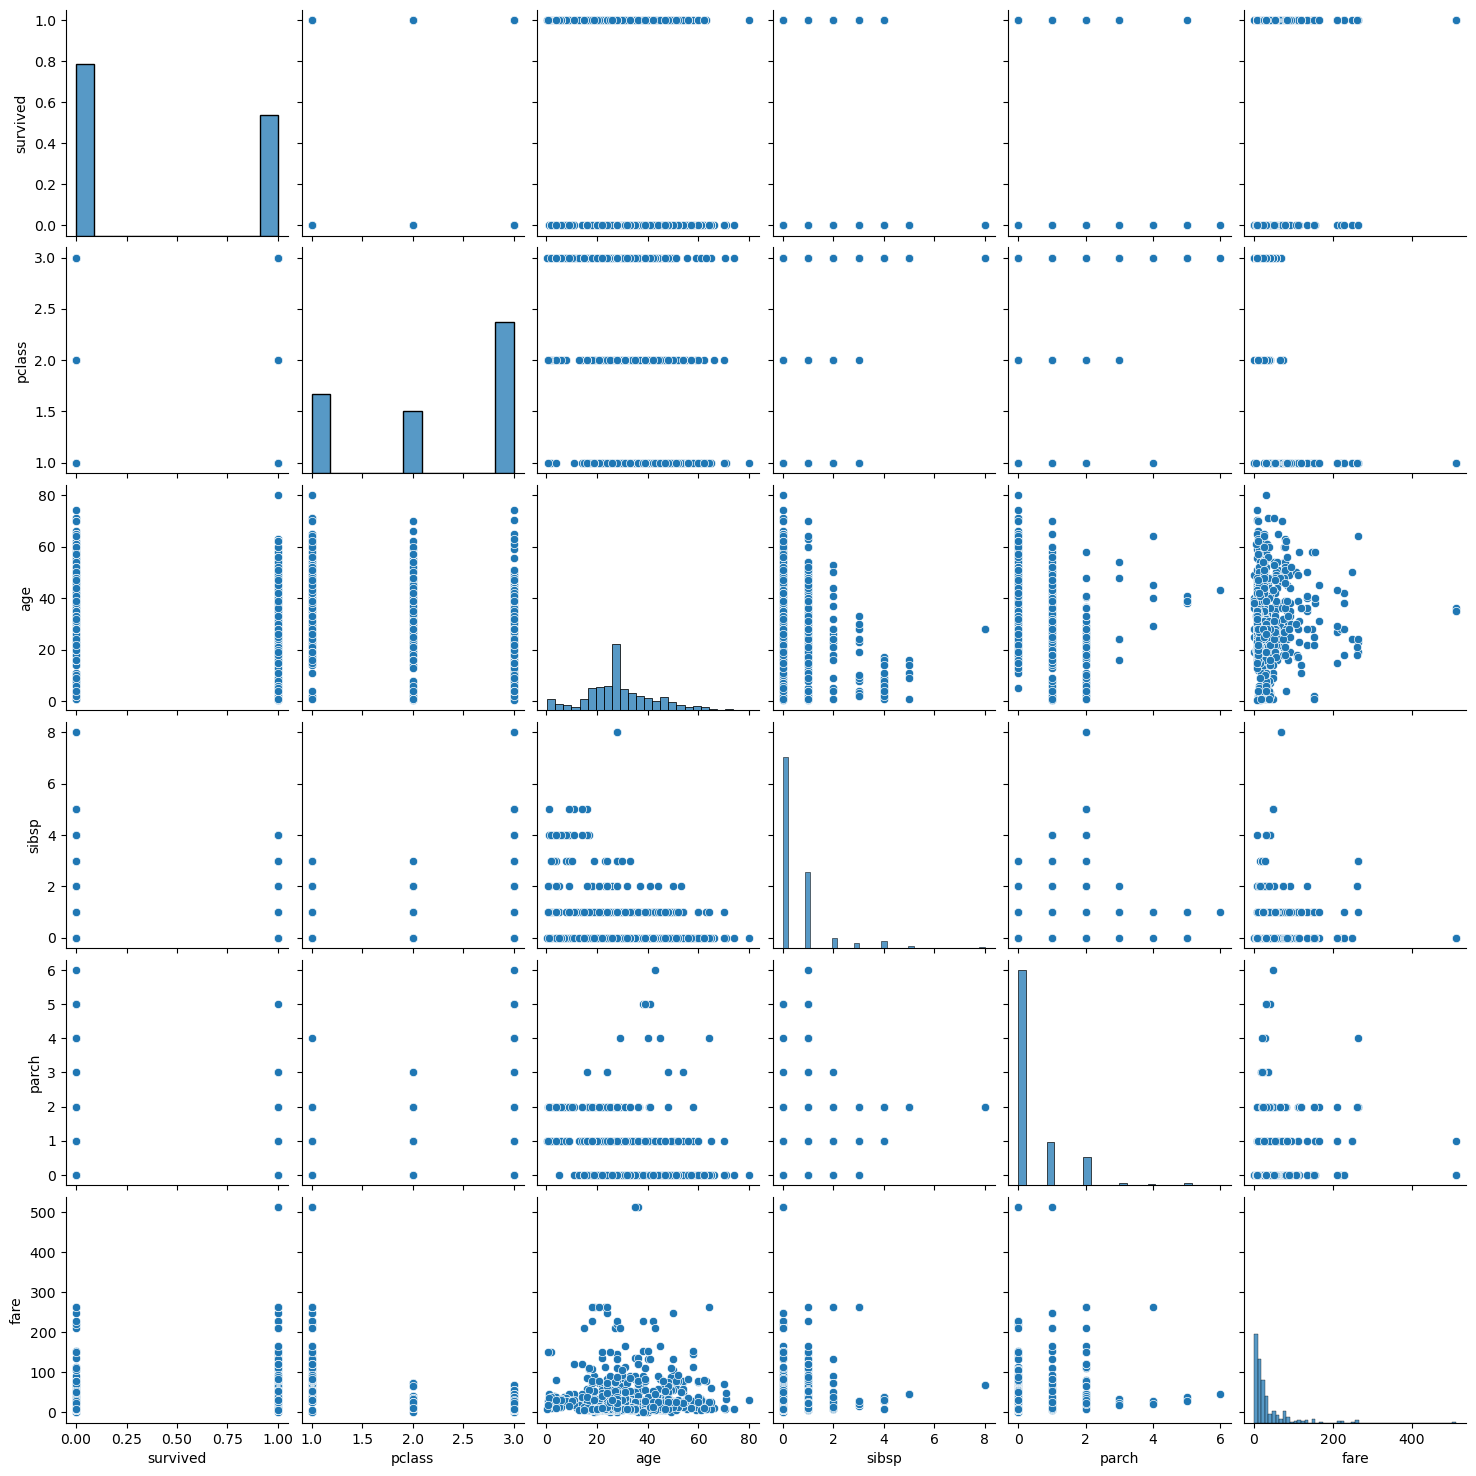

In [28]:
sns.pairplot(df[num_cols])
plt.show()

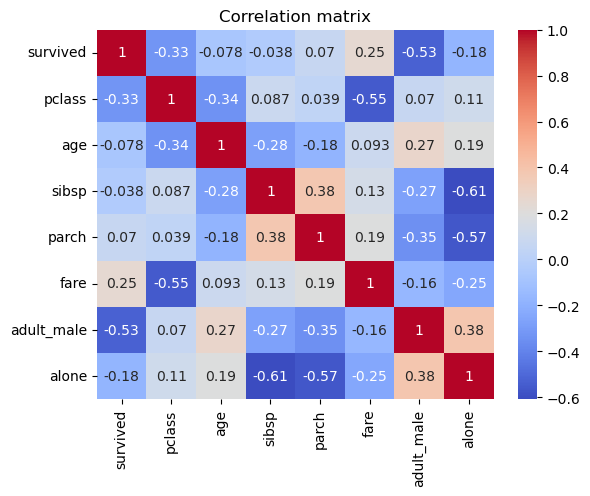

In [31]:
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.title('Correlation matrix')
plt.show()

Observations:
- fare positively correlates with survival
- pclass negatively correlates with survival
- age has weak correlation with survival


Insights:
- Higher fare (better class) increases survival probability
- Passenger class is a strong predictor of survival
- Age alone is not a strong predictor

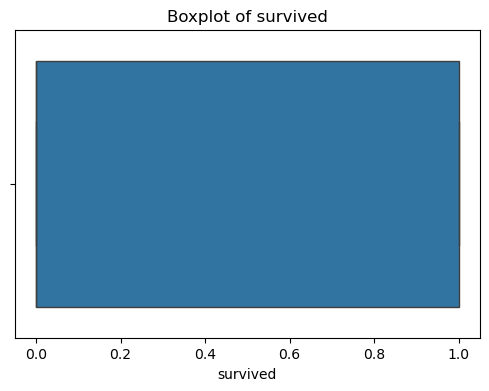

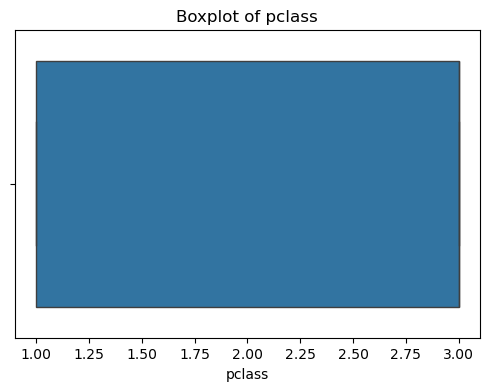

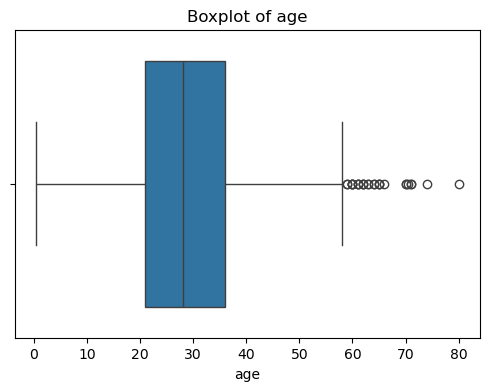

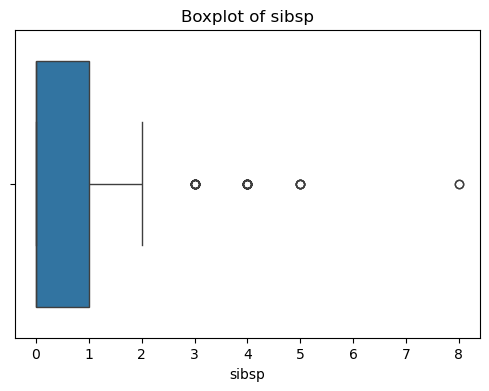

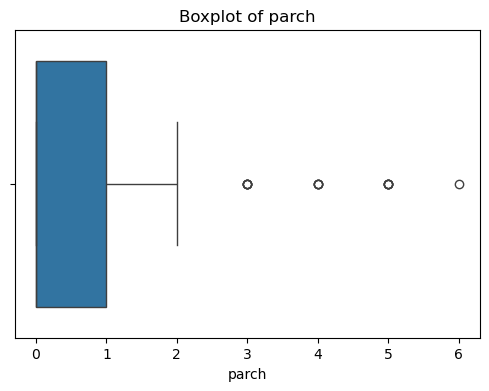

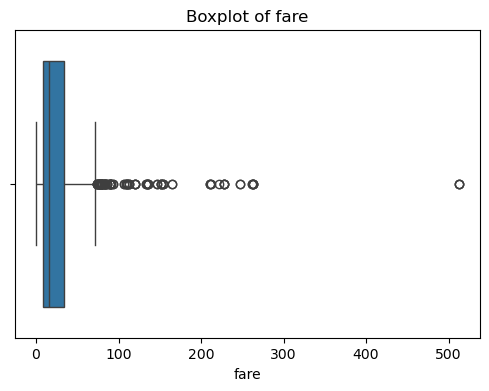

In [32]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Observations:
- Significant number of high-value outliers


Insights:
- Outliers represent real premium passengers
- Should not be removed → transformation preferred

In [35]:
def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers

outliers_fare = detect_outliers('fare')
len(outliers_fare)

102

In [36]:
df['log_fare'] = np.log1p(df['fare'])

In [37]:
df[num_cols].mean()
df[num_cols].median()
df[num_cols].std()
df[num_cols].skew()
df[num_cols].kurt()

survived    -1.879198
pclass      -1.449724
age          0.567323
sibsp       12.608666
parch        8.837563
fare        29.905898
dtype: float64

In [38]:
df['family_size'] = df['sibsp'] + df['parch'] + 1

In [48]:
df_encoded = pd.get_dummies(df,drop_first=True)
df_encoded

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,log_fare,family_size,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,embark_town_Queenstown,embark_town_Southampton,alive_yes
0,0,3,22.0,1,0,7.2500,True,False,2.110213,2,True,False,True,False,True,True,False,False,True,False
1,1,1,38.0,1,0,71.2833,False,False,4.280593,2,False,False,False,False,False,False,True,False,False,True
2,1,3,26.0,0,0,7.9250,False,True,2.188856,1,False,False,True,False,True,False,True,False,True,True
3,1,1,35.0,1,0,53.1000,False,False,3.990834,2,False,False,True,False,False,False,True,False,True,True
4,0,3,35.0,0,0,8.0500,True,True,2.202765,1,True,False,True,False,True,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,39.0,0,5,29.1250,False,False,3.405355,6,False,True,False,False,True,False,True,True,False,False
887,1,1,19.0,0,0,30.0000,False,True,3.433987,1,False,False,True,False,False,False,True,False,True,True
888,0,3,28.0,1,2,23.4500,False,False,3.196630,4,False,False,True,False,True,False,True,False,True,False
889,1,1,26.0,0,0,30.0000,True,True,3.433987,1,True,False,False,False,False,True,False,False,False,True


In [49]:
corr_matrix = df_encoded.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

df_encoded.drop(columns=to_drop, inplace=True)

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

num_cols = df_encoded.select_dtypes(include=['int64','float64']).columns

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

In [51]:
df_encoded

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,log_fare,family_size,sex_male,embarked_Q,embarked_S,class_Second,who_woman
0,-0.838628,0.883385,-0.551060,0.475876,-0.500754,-0.527515,True,False,-0.973913,0.033066,True,False,True,False,False
1,1.192424,-1.461216,0.611945,0.475876,-0.500754,0.695086,False,False,1.282761,0.033066,False,False,False,False,True
2,1.192424,0.883385,-0.260308,-0.534545,-0.500754,-0.514627,False,True,-0.892143,-0.624008,False,False,True,False,True
3,1.192424,-1.461216,0.393881,0.475876,-0.500754,0.347909,False,False,0.981481,0.033066,False,False,True,False,True
4,-0.838628,0.883385,0.393881,-0.534545,-0.500754,-0.512240,True,True,-0.877681,-0.624008,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,-0.838628,0.883385,0.684632,-0.534545,5.451465,-0.109851,False,False,0.372724,2.661361,False,True,False,False,True
887,1.192424,-1.461216,-0.769123,-0.534545,-0.500754,-0.093144,False,True,0.402494,-0.624008,False,False,True,False,True
888,-0.838628,0.883385,-0.114933,0.475876,1.880133,-0.218205,False,False,0.155700,1.347213,False,False,True,False,True
889,1.192424,-1.461216,-0.260308,-0.534545,-0.500754,-0.093144,True,True,0.402494,-0.624008,True,False,False,False,False
